In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [31]:
df = yf.download("NZDUSD=X", period="max")
df.head()
df.info()
df.describe()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.DataFrame'>
DatetimeIndex: 5820 entries, 2003-12-01 to 2026-05-06
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, NZDUSD=X)   5820 non-null   float64
 1   (High, NZDUSD=X)    5820 non-null   float64
 2   (Low, NZDUSD=X)     5820 non-null   float64
 3   (Open, NZDUSD=X)    5820 non-null   float64
 4   (Volume, NZDUSD=X)  5820 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 272.8 KB


Price,Close,High,Low,Open,Volume
Ticker,NZDUSD=X,NZDUSD=X,NZDUSD=X,NZDUSD=X,NZDUSD=X
count,5820.000000,5820.000000,5820.000000,5820.000000,5820.0
mean,0.695300,0.698796,0.692060,0.695293,0.0
std,0.076966,0.077934,0.076861,0.076957,0.0
min,0.492805,0.496598,0.490894,0.492999,0.0
25%,0.636478,0.639918,0.633231,0.636544,0.0
50%,0.691575,0.694529,0.688750,0.691766,0.0
75%,0.743025,0.746129,0.739221,0.743052,0.0
max,0.882379,1.221449,0.880282,0.882613,0.0


In [32]:
df.columns = ["Close", "High", "Low", "Open", "Volume"]
df = df.drop(columns= "Volume")
df["daily_return"] = df["Close"]/df["Close"].shift(1) - 1
df["daily_return"].describe()






count    5819.000000
mean        0.000016
std         0.007735
min        -0.065699
25%        -0.004214
50%         0.000088
75%         0.004563
max         0.054449
Name: daily_return, dtype: float64

In [33]:
df["daily_return"].idxmax()
df["daily_return"].nsmallest(5)

Date
2008-10-24   -0.065699
2008-10-06   -0.045518
2008-12-01   -0.042773
2025-04-07   -0.042375
2011-08-05   -0.041988
Name: daily_return, dtype: float64

In [34]:
grouped = df["daily_return"].groupby(df.index.year).std()
grouped.describe()
grouped.nlargest(5)         

Date
2008    0.013381
2009    0.011874
2011    0.009853
2004    0.009353
2007    0.008853
Name: daily_return, dtype: float64

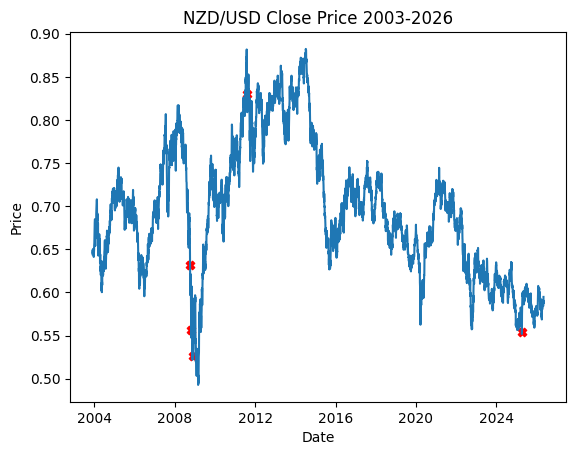

In [38]:
plt.plot(df.index, df["Close"])
worst_dates = df["daily_return"].nsmallest(5).index
plt.scatter(worst_dates, df.loc[worst_dates]["Close"], marker="X", color= "red")
plt.title("NZD/USD Close Price 2003-2026")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


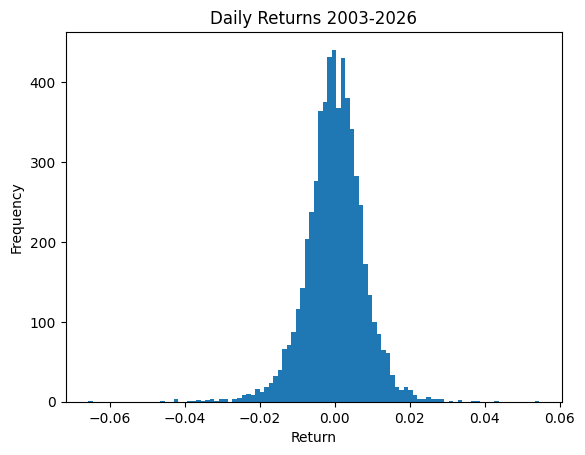

In [36]:
plt.hist(df["daily_return"], bins=100)
plt.title("Daily Returns 2003-2026")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

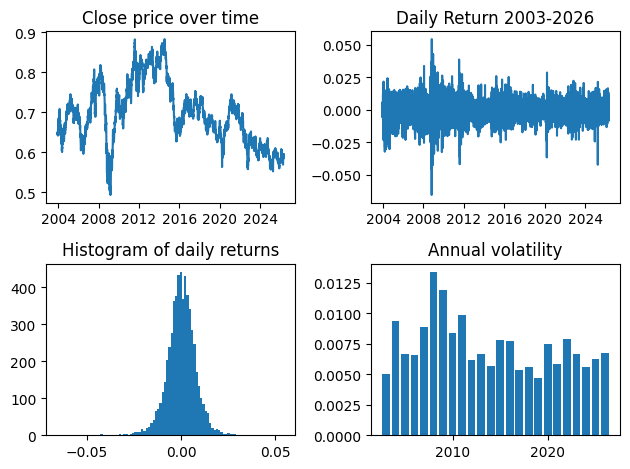

In [50]:
fig, axs = plt.subplots(2, 2)
axs[1,0].hist(df["daily_return"], bins=100)
axs[1,0].set_title("Histogram of daily returns")
axs[0,1].plot(df.index, df["daily_return"])
axs[0,1].set_title("Daily Return 2003-2026")
axs[0,0].plot(df.index, df["Close"])
axs[0,0].set_title("Close price over time")
axs[1,1].bar(grouped.index, grouped )
axs[1,1].set_title("Annual volatility")
plt.tight_layout()
# plt.show()